# Poster Figures — QCE (no titles, Figure 1 covers all four fault types)

Titles removed from all three -- add captions/labels directly on the poster instead.
Figure 1 now overlays all four fault types (toeplitz, final_key, reconciliation,
verify_digest) against one shared QBER line, rather than reconciliation alone.

Run `20_data_cleaning_and_integrity.ipynb` first for the cleaned CSVs.

In [2]:
import sys
from pathlib import Path
from math import comb, ceil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR / 'scripts'))
from qne.cascade.finite_key import h, finite_key_output_length
from qne.cascade.validation_utils import wilson_ci

RESULTS = PROJECT_DIR / "results"
POSTER_OUT = RESULTS / "poster_figures"
POSTER_OUT.mkdir(exist_ok=True)

key_pairs_df = pd.read_csv(str(RESULTS / "key_pairs_metadata.csv"))

fault_data = {
    "toeplitz":       (pd.read_csv(str(RESULTS / "toeplitz_clean.csv")), "prob"),
    "final_key":      (pd.read_csv(str(RESULTS / "final_key_clean.csv")), "prob"),
    "reconciliation": (pd.read_csv(str(RESULTS / "reconciliation_clean.csv")), "reconciliation_prob"),
    "verify_digest":  (pd.read_csv(str(RESULTS / "verify_digest_clean.csv")), "prob"),
}
for name, (df, _) in fault_data.items():
    df["mismatch"] = ~df["keys_match"].fillna(True)

# Poster-scale defaults -- big enough to read from a few feet away
plt.rcParams.update({
    "font.size": 22, "axes.labelsize": 24,
    "xtick.labelsize": 20, "ytick.labelsize": 20, "legend.fontsize": 18,
    "lines.linewidth": 3, "lines.markersize": 10, "axes.linewidth": 1.5,
})


## Figure 1 (headline): QBER flat, mismatch rate rising -- all four fault types

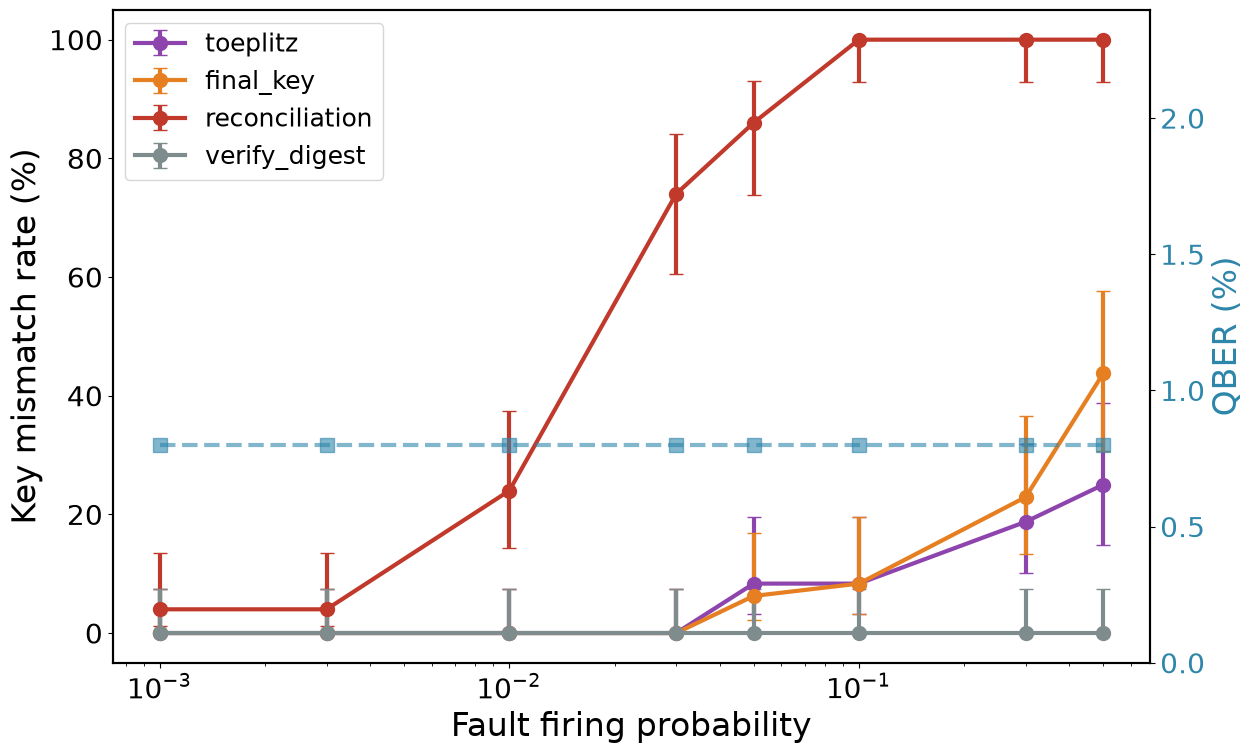

In [2]:
fig, ax1 = plt.subplots(figsize=(13, 8))
colors = {"toeplitz": "#8E44AD", "final_key": "#E67E22", "reconciliation": "#C0392B", "verify_digest": "#7F8C8D"}
qber_series = None

for name, (df, prob_col) in fault_data.items():
    probs = sorted(df[prob_col].unique())
    mismatch_mean, mismatch_lo, mismatch_hi = [], [], []
    for prob in probs:
        sub = df[df[prob_col] == prob]
        p_hat, lo, hi = wilson_ci(sub["mismatch"].sum(), len(sub))
        mismatch_mean.append(p_hat); mismatch_lo.append(lo); mismatch_hi.append(hi)
    mismatch_mean, mismatch_lo, mismatch_hi = np.array(mismatch_mean), np.array(mismatch_lo), np.array(mismatch_hi)

    ax1.errorbar(probs, mismatch_mean * 100,
                 yerr=[np.clip((mismatch_mean - mismatch_lo) * 100, 0, None),
                       np.clip((mismatch_hi - mismatch_mean) * 100, 0, None)],
                 fmt="o-", color=colors[name], capsize=5, label=name)

    if qber_series is None and "qber" in df.columns:
        qber_series = df.groupby(prob_col)["qber"].mean()

ax1.set_xscale("log")
ax1.set_xlabel("Fault firing probability")
ax1.set_ylabel("Key mismatch rate (%)")
ax1.set_ylim(-5, 105)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
if qber_series is not None:
    ax2.plot(qber_series.index, qber_series.values * 100, "s--", color="#2E86AB", label="QBER", alpha=0.6)
ax2.set_ylabel("QBER (%)", color="#2E86AB")
ax2.tick_params(axis="y", labelcolor="#2E86AB")
ax2.set_ylim(0, (qber_series.max() * 100 * 3) if qber_series is not None else 5)

fig.tight_layout()
plt.savefig(str(POSTER_OUT / "fig1_headline_qber_vs_mismatch.png"), dpi=200, bbox_inches="tight")
plt.show()


## Figure 2: Mitigation comparison -- TMR (rising failure) vs. redundant PA (flat, safe)

Same panel, two lines: TMR's failure rate climbs with fault probability (pool-size
collision effect), while redundant PA stays flat near 0% -- it operates over the
whole key, so independent-replica collisions are vanishingly rare. The visual
contrast carries the mitigation-comparison point without a separate bullet or figure.

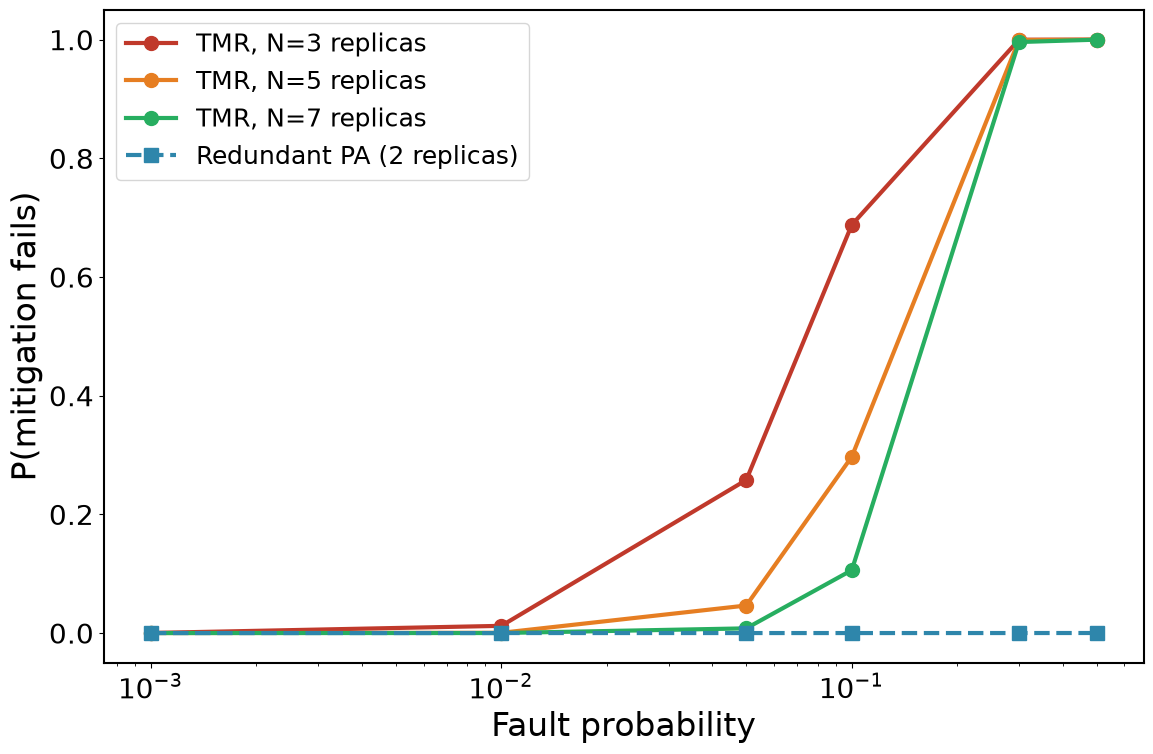

In [3]:
def exact_majority_vote_failure(pool_size, p, n_replicas):
    """TMR mechanism: pool_size candidate positions, each independently at risk
    of being outvoted -- correct for reconciliation faults, which strike one of
    a small, SHARED set of positions across all replicas."""
    p_bit_wrong_after_vote = 1 - binom.cdf(n_replicas // 2, n_replicas, p)
    return 1 - (1 - p_bit_wrong_after_vote) ** pool_size

def redundant_pa_collision_failure(p, output_length):
    """Different mechanism -- each firing flips ONE specific output bit (not a
    shared pool of candidates). A silent (undetected) failure needs BOTH
    independent replicas to fire (p^2) AND land on the exact same bit
    (~1/output_length, since each pick is uniformly random over the output).
    This is why redundant PA stays safe even though it uses the same
    'independent replicas' idea as TMR -- the collision geometry is different."""
    return (p ** 2) / output_length

POOL_SIZE = 41       # real transmission-error positions, key0 (n_bits=3504, qber=0.0128) -- swap in your key
OUTPUT_LENGTH = 3504  # PA output length -- swap in your key's actual ell
fault_probs = np.array([1e-3, 1e-2, 0.05, 0.1, 0.3, 0.5])

fig, ax = plt.subplots(figsize=(12, 8))
colors = {"3": "#C0392B", "5": "#E67E22", "7": "#27AE60"}
for n_rep in [3, 5, 7]:
    fail_rates = [exact_majority_vote_failure(POOL_SIZE, p, n_rep) for p in fault_probs]
    ax.plot(fault_probs, fail_rates, "o-", label=f"TMR, N={n_rep} replicas", color=colors[str(n_rep)])

redundant_pa_fail = [redundant_pa_collision_failure(p, OUTPUT_LENGTH) for p in fault_probs]
ax.plot(fault_probs, redundant_pa_fail, "s--", label="Redundant PA (2 replicas)", color="#2E86AB", linewidth=3)

ax.set_xscale("log")
ax.set_xlabel("Fault probability")
ax.set_ylabel("P(mitigation fails)")
ax.legend()
ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
plt.savefig(str(POSTER_OUT / "fig2_mitigation_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()

## Figure 3: Finite-key vs. asymptotic length, per key

Also fault-type-independent -- key length depends on QBER/n_bits, not which SDC
fault is being tested.

   key  ell_asymptotic  ell_finite  reduction_pct
0    0            2810          23      99.181495
1    1            2608           1      99.961656
2    2            3180         337      89.402516
3    3            3251         363      88.834205
4    4            3131         269      91.408496

Mean reduction: 93.8%  (range 88.8-100.0%)


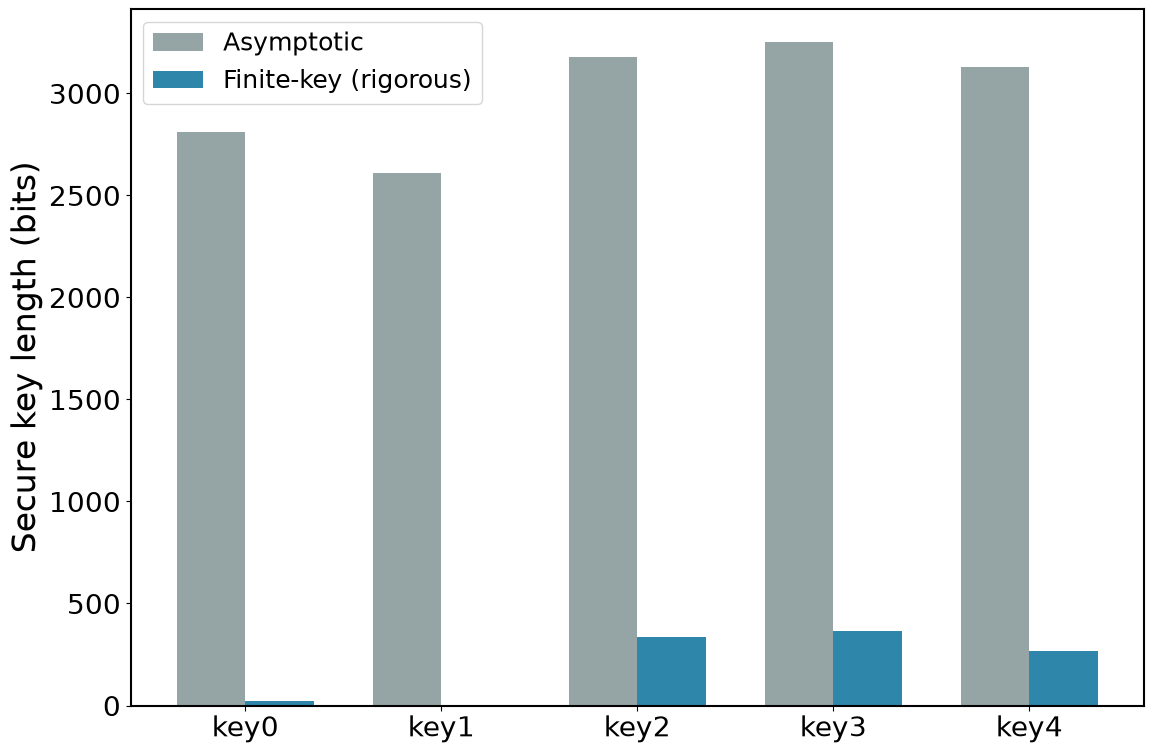

In [4]:
rows = []
for _, row in key_pairs_df.iterrows():
    n_bits, k_pe, qber = int(row["n_bits"]), int(row["k_pe"]), float(row["qber"])
    ell_asymp = max(0, int(n_bits * (1 - 2 * h(qber))))
    ell_fk, _, _, _ = finite_key_output_length(n_bits, k_pe, qber)
    rows.append({"key": int(row["index"]), "ell_asymptotic": ell_asymp, "ell_finite": ell_fk,
                 "reduction_pct": 100 * (1 - ell_fk / ell_asymp) if ell_asymp > 0 else float("nan")})

df_fk = pd.DataFrame(rows)
mean_reduction = df_fk["reduction_pct"].mean()
print(df_fk)
print(f"\nMean reduction: {mean_reduction:.1f}%  (range {df_fk['reduction_pct'].min():.1f}-{df_fk['reduction_pct'].max():.1f}%)")

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(df_fk))
width = 0.35
ax.bar(x - width/2, df_fk["ell_asymptotic"], width, label="Asymptotic", color="#95A5A6")
ax.bar(x + width/2, df_fk["ell_finite"], width, label="Finite-key (rigorous)", color="#2E86AB")

ax.set_xticks(x)
ax.set_xticklabels([f"key{k}" for k in df_fk["key"]])
ax.set_ylabel("Secure key length (bits)")
ax.legend()
fig.tight_layout()
plt.savefig(str(POSTER_OUT / "fig3_finitekey_reduction.png"), dpi=200, bbox_inches="tight")
plt.show()


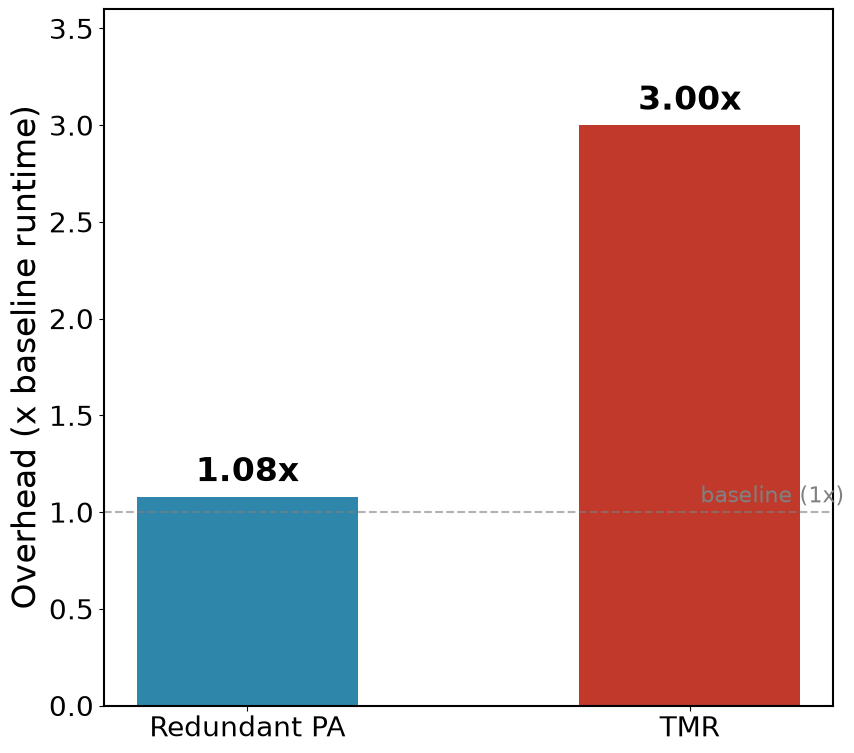

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 22, "axes.labelsize": 24,
    "xtick.labelsize": 20, "ytick.labelsize": 20,
    "axes.linewidth": 1.5,
})

labels = ["Redundant PA", "TMR"]
overhead = [1.08, 3.00]  # redundant PA: compute (its only real cost); TMR: real-channel
colors = ["#2E86AB", "#C0392B"]

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.bar(labels, overhead, color=colors, width=0.5)

for bar, val in zip(bars, overhead):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.08, f"{val:.2f}x",
            ha="center", fontsize=24, fontweight="bold")

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1.5, alpha=0.6)
ax.text(1.35, 1.05, "baseline (1x)", fontsize=16, color="gray", ha="right")

ax.set_ylabel("Overhead (x baseline runtime)")
ax.set_ylim(0, 3.6)
fig.tight_layout()
plt.savefig(str(POSTER_OUT / "fig_overhead_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()

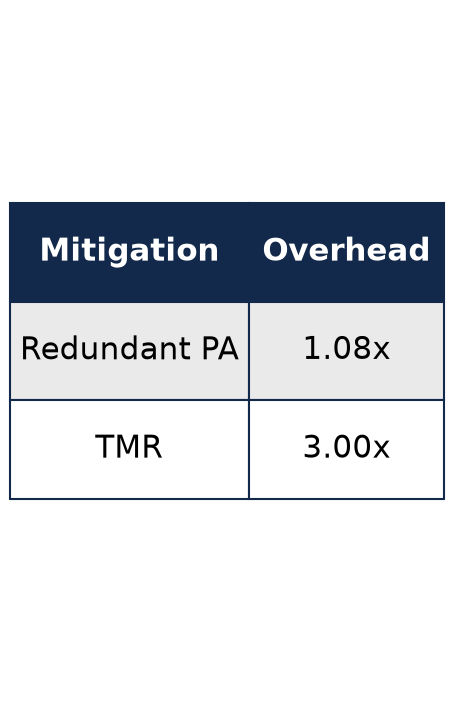

In [4]:
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 22})

fig, ax = plt.subplots(figsize=(5, 7.5))
ax.axis("off")

data = [
    ["Redundant PA", "1.08x"],
    ["TMR",          "3.00x"],
]
col_labels = ["Mitigation", "Overhead"]

table = ax.table(
    cellText=data, colLabels=col_labels,
    cellLoc="center", loc="center",
    colWidths=[0.55, 0.45],
)
table.auto_set_font_size(False)
table.set_fontsize(22)
table.scale(1, 5.0)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#13294B")
    cell.set_linewidth(1.5)
    if row == 0:
        cell.set_facecolor("#13294B")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor("#EAEAEA" if row % 2 == 1 else "white")

fig.tight_layout()
plt.savefig(str(POSTER_OUT / "fig_overhead_table.png"), dpi=200, bbox_inches="tight")
plt.show()